In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("water_flows.csv", sep=";")

In [4]:
df.head()


,Timestamp,p227,p235,PUMP_1
0,2018-01-01 00:00:00,"77,77","83,93","44,04"
1,2018-01-01 00:05:00,"72,51","76,34","44,06"
2,2018-01-01 00:10:00,"71,54","78,68","44,06"
3,2018-01-01 00:15:00,"69,85","75,5","44,07"
4,2018-01-01 00:20:00,"77,12","82,99","44,03"


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105120 entries, 0 to 105119
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Timestamp  105120 non-null  object
 1   p227       105120 non-null  object
 2   p235       105120 non-null  object
 3   PUMP_1     105120 non-null  object
dtypes: object(4)
memory usage: 3.2+ MB


In [6]:
df.shape

(105120, 4)

In [7]:
df.isnull().sum()

Timestamp    0
p227         0
p235         0
PUMP_1       0
dtype: int64

In [8]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [9]:
df.dtypes

Timestamp    datetime64[ns]
p227                 object
p235                 object
PUMP_1               object
dtype: object

In [10]:
df['Timestamp'].head()

0   2018-01-01 00:00:00
1   2018-01-01 00:05:00
2   2018-01-01 00:10:00
3   2018-01-01 00:15:00
4   2018-01-01 00:20:00
Name: Timestamp, dtype: datetime64[ns]

In [11]:
df['Timestamp'].tail()

105115   2018-12-31 23:35:00
105116   2018-12-31 23:40:00
105117   2018-12-31 23:45:00
105118   2018-12-31 23:50:00
105119   2018-12-31 23:55:00
Name: Timestamp, dtype: datetime64[ns]

In [12]:
df['p227'] = df['p227'].str.replace(',', '.').astype(float)
df['p235'] = df['p235'].str.replace(',', '.').astype(float)
df['PUMP_1'] = df['PUMP_1'].str.replace(',', '.').astype(float)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105120 entries, 0 to 105119
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Timestamp  105120 non-null  datetime64[ns]
 1   p227       105120 non-null  float64       
 2   p235       105120 non-null  float64       
 3   PUMP_1     105120 non-null  float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 3.2 MB


In [14]:
print("Duplicate timestamps:", df['Timestamp'].duplicated().sum())

Duplicate timestamps: 0


In [15]:
df = df.sort_values('Timestamp')

In [16]:
df[['Timestamp', 'p227', 'p235', 'PUMP_1']].head()

,Timestamp,p227,p235,PUMP_1
0,2018-01-01 00:00:00,77.77,83.93,44.04
1,2018-01-01 00:05:00,72.51,76.34,44.06
2,2018-01-01 00:10:00,71.54,78.68,44.06
3,2018-01-01 00:15:00,69.85,75.50,44.07
4,2018-01-01 00:20:00,77.12,82.99,44.03


In [17]:
df = df.set_index('Timestamp')


In [18]:
df.head()

,p227,p235,PUMP_1
Timestamp,,,
2018-01-01 00:00:00,77.77,83.93,44.04
2018-01-01 00:05:00,72.51,76.34,44.06
2018-01-01 00:10:00,71.54,78.68,44.06
2018-01-01 00:15:00,69.85,75.50,44.07
2018-01-01 00:20:00,77.12,82.99,44.03


In [19]:
df.index.to_series().diff().value_counts().head()

Timestamp
0 days 00:05:00    105119
Name: count, dtype: int64

In [20]:
df.describe()

,p227,p235,PUMP_1
count,105120.000000,105120.000000,105120.000000
mean,98.200478,103.496288,26.838853
std,29.967830,31.230732,21.457418
min,15.930000,17.170000,0.000000
25%,78.380000,83.440000,0.000000
50%,104.930000,110.060000,43.910000
75%,121.150000,126.292500,44.020000
max,166.440000,195.280000,44.400000


In [21]:
df.tail()




,p227,p235,PUMP_1
Timestamp,,,
2018-12-31 23:35:00,91.56,94.41,44.02
2018-12-31 23:40:00,92.27,97.59,44.00
2018-12-31 23:45:00,89.18,92.87,44.02
2018-12-31 23:50:00,92.63,95.29,44.00
2018-12-31 23:55:00,84.53,86.91,44.04


In [22]:
print(type(df.index))

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [23]:
print(df.index.min())
print(df.index.max())

2018-01-01 00:00:00
2018-12-31 23:55:00


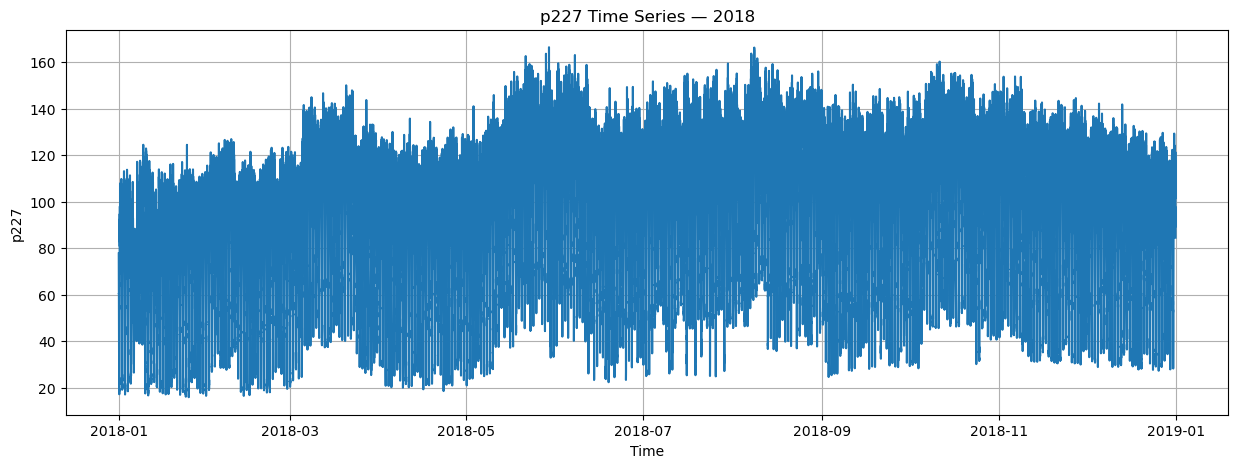

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(df.index, df["p227"])

plt.title("p227 Time Series — 2018")
plt.xlabel("Time")
plt.ylabel("p227")
plt.grid(True)

plt.show()

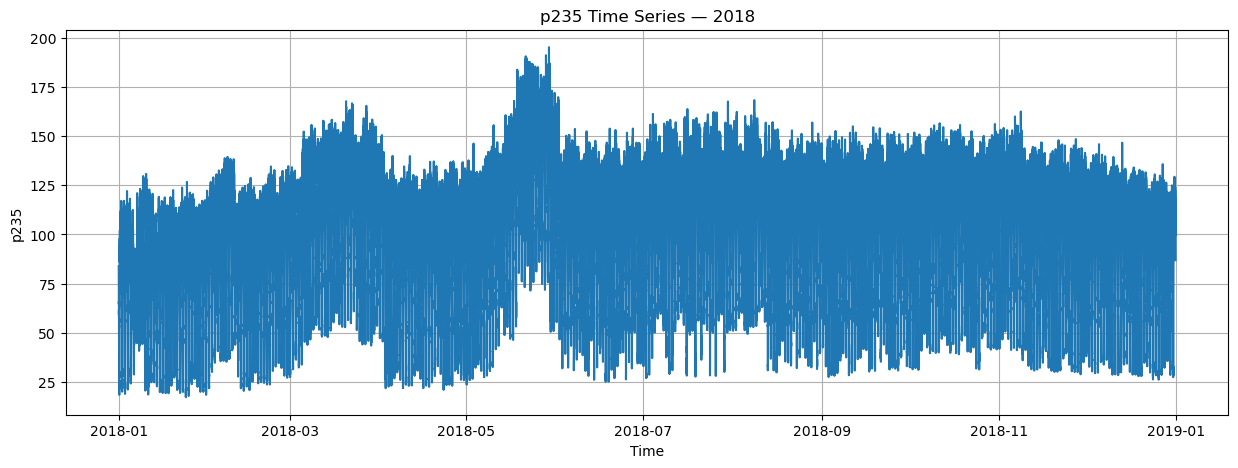

In [25]:
plt.figure(figsize=(15, 5))

plt.plot(df.index, df["p235"])

plt.title("p235 Time Series — 2018")
plt.xlabel("Time")
plt.ylabel("p235")
plt.grid(True)

plt.show()


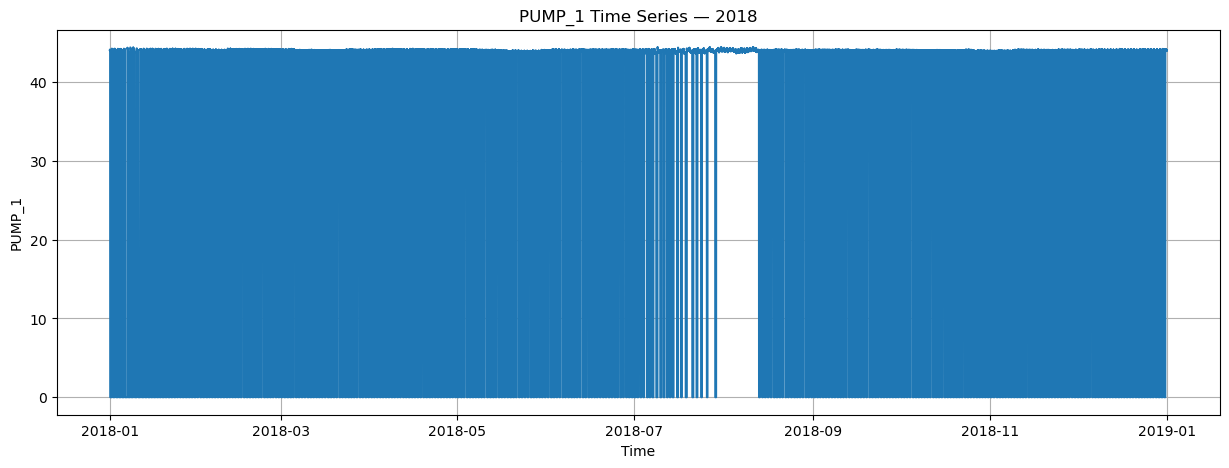

In [26]:
plt.figure(figsize=(15, 5))

plt.plot(df.index, df["PUMP_1"])

plt.title("PUMP_1 Time Series — 2018")
plt.xlabel("Time")
plt.ylabel("PUMP_1")
plt.grid(True)

plt.show()

In [27]:
daily_avg = df[["p227", "p235", "PUMP_1"]].resample("D").mean()

daily_avg.head()

,p227,p235,PUMP_1
Timestamp,,,
2018-01-01,76.542813,80.857778,18.211562
2018-01-02,78.268160,82.500417,20.960417
2018-01-03,74.680903,78.674097,14.235972
2018-01-04,77.297222,81.813160,18.524687
2018-01-05,71.498437,75.848437,12.713160


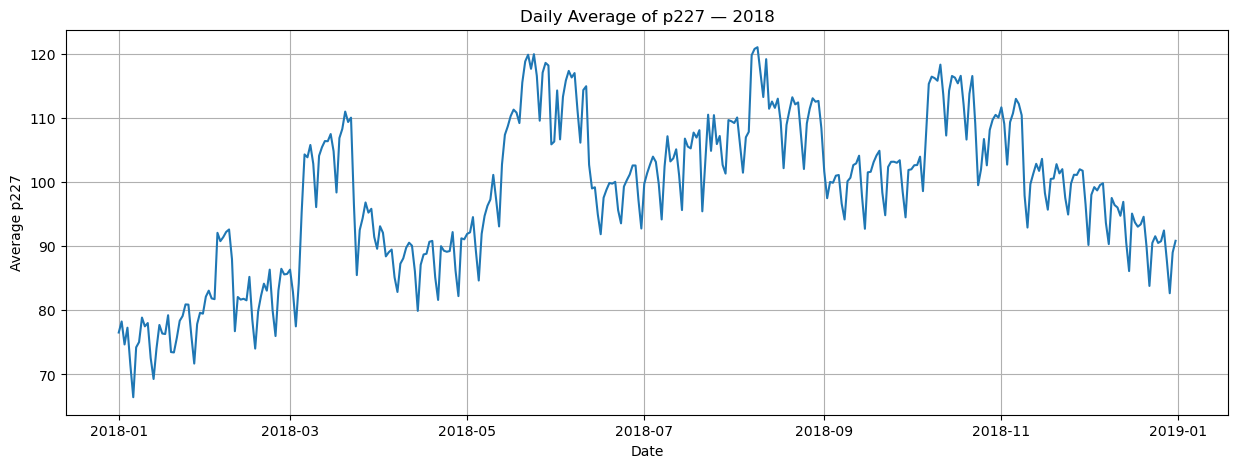

In [28]:
plt.figure(figsize=(15, 5))

plt.plot(daily_avg.index, daily_avg["p227"])

plt.title("Daily Average of p227 — 2018")
plt.xlabel("Date")
plt.ylabel("Average p227")
plt.grid(True)

plt.show()

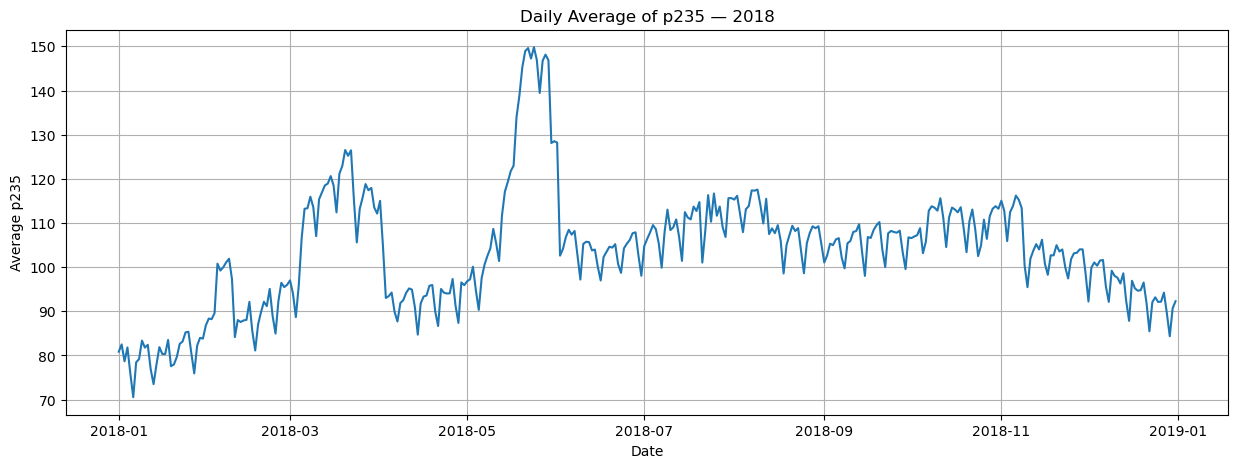

In [29]:
plt.figure(figsize=(15, 5))

plt.plot(daily_avg.index, daily_avg["p235"])

plt.title("Daily Average of p235 — 2018")
plt.xlabel("Date")
plt.ylabel("Average p235")
plt.grid(True)

plt.show()

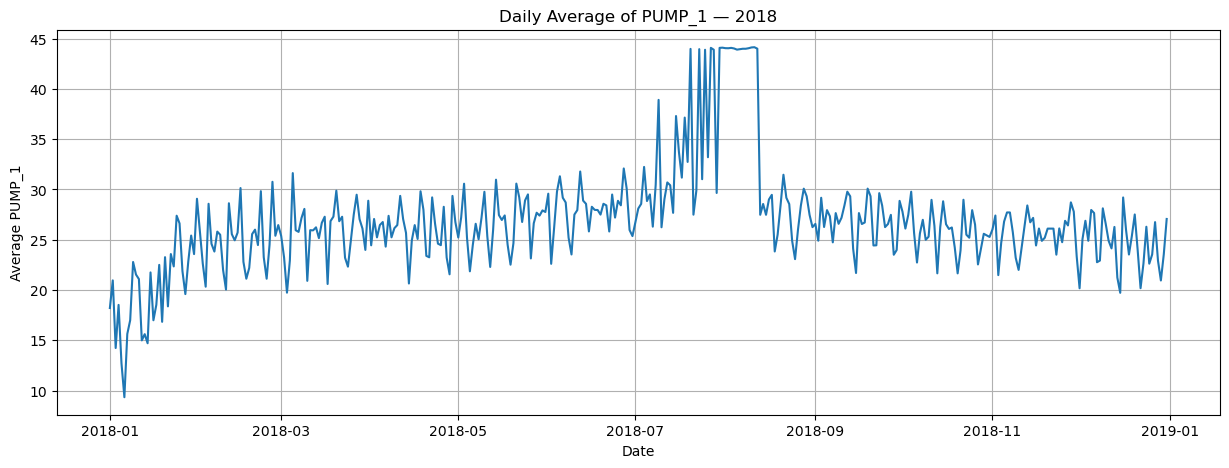

In [30]:
plt.figure(figsize=(15, 5))

plt.plot(daily_avg.index, daily_avg["PUMP_1"])

plt.title("Daily Average of PUMP_1 — 2018")
plt.xlabel("Date")
plt.ylabel("Average PUMP_1")
plt.grid(True)

plt.show()

In [31]:
df["day_of_week"] = df.index.dayofweek

weekly_pattern = df.groupby("day_of_week")[["p227", "p235", "PUMP_1"]].mean()

weekly_pattern

,p227,p235,PUMP_1
day_of_week,,,
0,99.615949,104.697666,28.165243
1,100.239561,105.349058,27.100509
2,99.857228,105.045567,27.948875
3,100.799627,106.210433,28.251659
4,96.512484,102.196157,25.881259
5,91.899141,97.266189,23.999998
6,98.452135,103.685841,26.498919


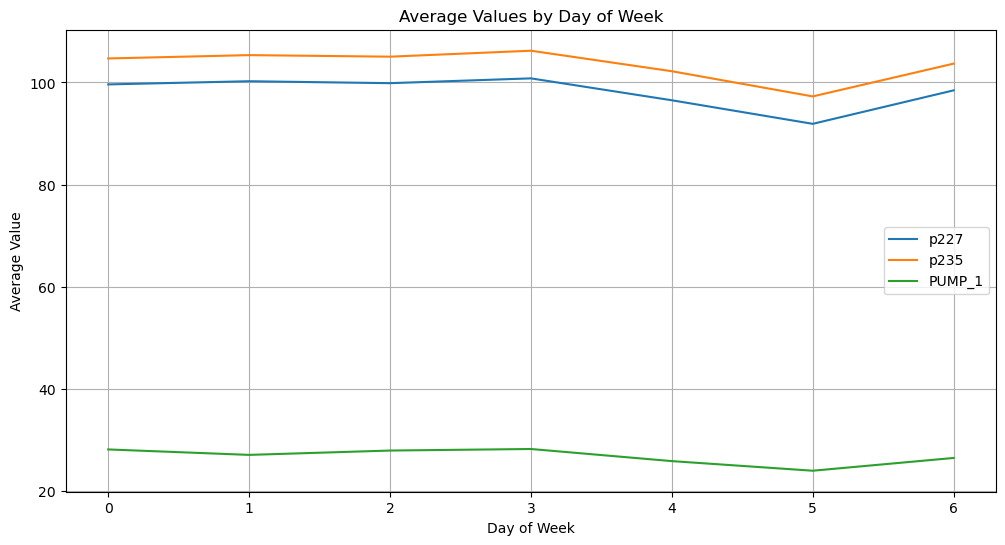

In [32]:
weekly_pattern.plot(figsize=(12, 6))

plt.title("Average Values by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Value")
plt.grid(True)

plt.show()


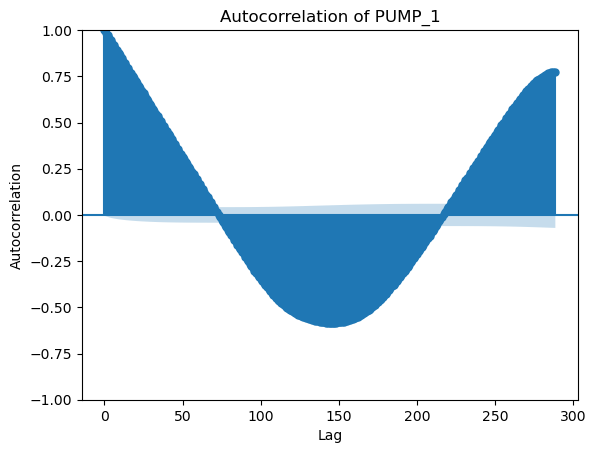

In [33]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(df["PUMP_1"], lags=288)

plt.title("Autocorrelation of PUMP_1")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")

plt.show()

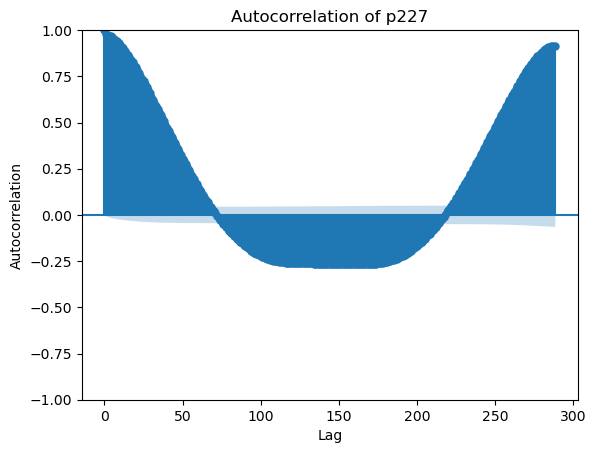

In [34]:
plot_acf(df["p227"], lags=288)

plt.title("Autocorrelation of p227")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")

plt.show()

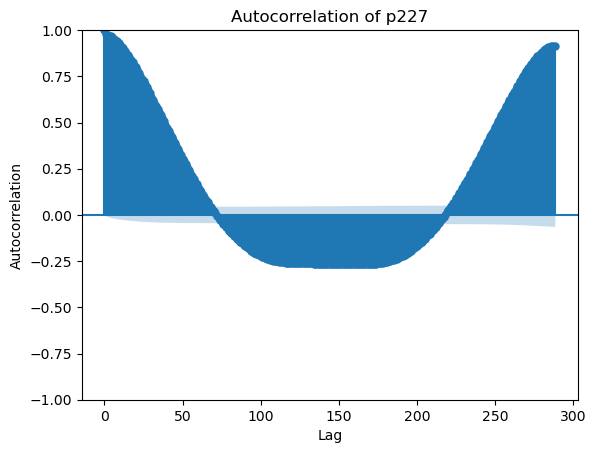

In [35]:
plot_acf(df["p227"], lags=288)

plt.title("Autocorrelation of p227")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")

plt.show()

In [36]:
from statsmodels.tsa.stattools import adfuller

result_p227 = adfuller(df["p227"])

print("p227 ADF Statistic:", result_p227[0])
print("p227 p-value:", result_p227[1])


p227 ADF Statistic: -35.859841702248914
p227 p-value: 0.0


In [37]:
result_p235 = adfuller(df["p235"])

print("p235 ADF Statistic:", result_p235[0])
print("p235 p-value:", result_p235[1])

p235 ADF Statistic: -34.66600975416475
p235 p-value: 0.0


In [38]:
result_pump = adfuller(df["PUMP_1"])

print("PUMP_1 ADF Statistic:", result_pump[0])
print("PUMP_1 p-value:", result_pump[1])

PUMP_1 ADF Statistic: -37.07134968666314
PUMP_1 p-value: 0.0


In [39]:
forecast_df = df[["p227", "p235", "PUMP_1"]].copy()

forecast_df.head()

,p227,p235,PUMP_1
Timestamp,,,
2018-01-01 00:00:00,77.77,83.93,44.04
2018-01-01 00:05:00,72.51,76.34,44.06
2018-01-01 00:10:00,71.54,78.68,44.06
2018-01-01 00:15:00,69.85,75.50,44.07
2018-01-01 00:20:00,77.12,82.99,44.03


In [40]:
forecast_df.shape

(105120, 3)

In [41]:
forecast_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 105120 entries, 2018-01-01 00:00:00 to 2018-12-31 23:55:00
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   p227    105120 non-null  float64
 1   p235    105120 non-null  float64
 2   PUMP_1  105120 non-null  float64
dtypes: float64(3)
memory usage: 3.2 MB


In [42]:
forecast_df.index.freq

In [43]:
n = len(forecast_df)

train_size = int(n * 0.76)
validation_size = int(n * 0.12)

print("Total:", n)
print("Training:", train_size)
print("Validation:", validation_size)
print("Testing:", n - train_size - validation_size)

Total: 105120
Training: 79891
Validation: 12614
Testing: 12615


In [44]:
train = forecast_df.iloc[:train_size]
validation = forecast_df.iloc[train_size:train_size + validation_size]
test = forecast_df.iloc[train_size + validation_size:]

In [45]:
print("Training:", train.shape)
print("Validation:", validation.shape)
print("Testing:", test.shape)

Training: (79891, 3)
Validation: (12614, 3)
Testing: (12615, 3)


In [46]:
print("TRAIN")
print(train.index.min())
print(train.index.max())

print("\nVALIDATION")
print(validation.index.min())
print(validation.index.max())

print("\nTEST")
print(test.index.min())
print(test.index.max())

TRAIN
2018-01-01 00:00:00
2018-10-05 09:30:00

VALIDATION
2018-10-05 09:35:00
2018-11-18 04:40:00

TEST
2018-11-18 04:45:00
2018-12-31 23:55:00


In [47]:
train.index.max() < validation.index.min()

validation.index.max() < test.index.min()

True

In [48]:
print(len(train) + len(validation) + len(test))

105120


In [49]:
y_train = train["PUMP_1"]
y_validation = validation["PUMP_1"]
y_test = test["PUMP_1"]

In [50]:
print("Training:", y_train.shape)
print("Validation:", y_validation.shape)
print("Testing:", y_test.shape)

Training: (79891,)
Validation: (12614,)
Testing: (12615,)


In [51]:
import numpy as np

naive_validation = np.concatenate([
    [y_train.iloc[-1]],
    y_validation.iloc[:-1].values
])

print("Naive validation predictions:", len(naive_validation))

Naive validation predictions: 12614


In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(
    y_validation,
    naive_validation
)

rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        naive_validation
    )
)

print("Naïve Forecast MAE:", mae)
print("Naïve Forecast RMSE:", rmse)

Naïve Forecast MAE: 0.3233058506421436
Naïve Forecast RMSE: 3.6727777089788463


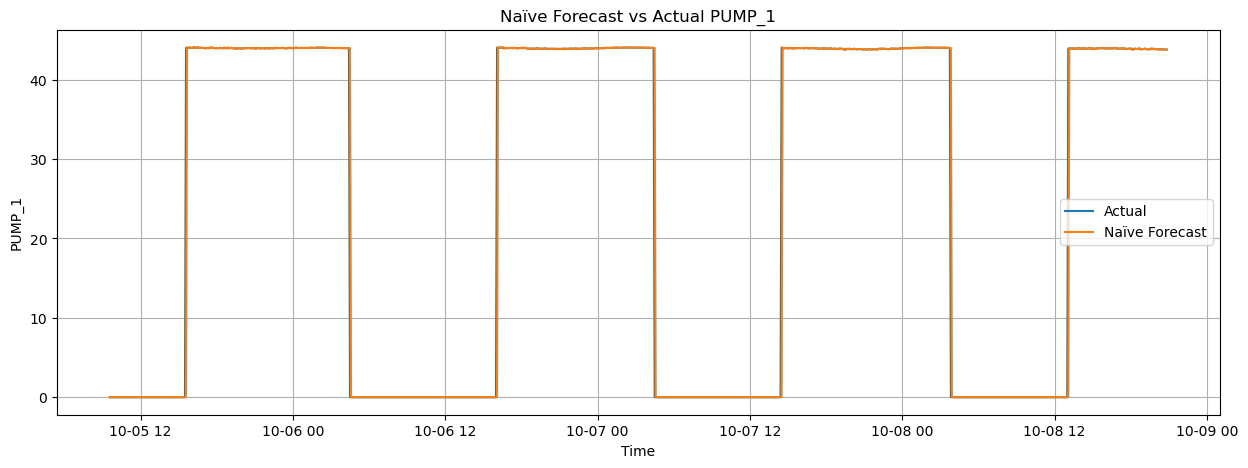

In [53]:
plt.figure(figsize=(15, 5))

plt.plot(
    y_validation.index[:1000],
    y_validation.iloc[:1000],
    label="Actual"
)

plt.plot(
    y_validation.index[:1000],
    naive_validation[:1000],
    label="Naïve Forecast"
)

plt.title("Naïve Forecast vs Actual PUMP_1")
plt.xlabel("Time")
plt.ylabel("PUMP_1")
plt.legend()
plt.grid(True)

plt.show()

In [54]:
forecast_df = forecast_df.asfreq("5min")

In [55]:
print(forecast_df.index.freq)

<5 * Minutes>


In [56]:
train = forecast_df.iloc[:train_size]
validation = forecast_df.iloc[train_size:train_size + validation_size]
test = forecast_df.iloc[train_size + validation_size:]

In [57]:
y_train = train["PUMP_1"]
y_validation = validation["PUMP_1"]
y_test = test["PUMP_1"]

In [58]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(
    y_train,
    order=(5, 0, 0)
)

arima_model = model.fit()

print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:                 PUMP_1   No. Observations:                79891
Model:                 ARIMA(5, 0, 0)   Log Likelihood             -213503.057
Date:                Fri, 04 Sep 2026   AIC                         427020.114
Time:                        13:06:36   BIC                         427085.133
Sample:                    01-01-2018   HQIC                        427040.047
                         - 10-05-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         27.3385      8.542      3.201      0.001      10.597      44.080
ar.L1          0.9930      0.155      6.423      0.000       0.690       1.296
ar.L2       3.342e-05      0.216      0.000      1.0

In [59]:
arima_validation = arima_model.forecast(
    steps=len(y_validation)
)

print("Forecasted observations:", len(arima_validation))

Forecasted observations: 12614


In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

arima_mae = mean_absolute_error(
    y_validation,
    arima_validation
)

arima_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        arima_validation
    )
)

print("ARIMA Validation MAE:", arima_mae)
print("ARIMA Validation RMSE:", arima_rmse)

ARIMA Validation MAE: 21.015637641500067
ARIMA Validation RMSE: 21.681613939020384


In [61]:
print("===== MODEL COMPARISON =====")

print("Naïve MAE :", mae)
print("ARIMA MAE :", arima_mae)

print()

print("Naïve RMSE:", rmse)
print("ARIMA RMSE:", arima_rmse)

===== MODEL COMPARISON =====
Naïve MAE : 0.3233058506421436
ARIMA MAE : 21.015637641500067

Naïve RMSE: 3.6727777089788463
ARIMA RMSE: 21.681613939020384


In [62]:
model_101 = ARIMA(
    y_train,
    order=(1, 0, 1)
)

arima_101 = model_101.fit()

print(arima_101.summary())

                               SARIMAX Results                                
Dep. Variable:                 PUMP_1   No. Observations:                79891
Model:                 ARIMA(1, 0, 1)   Log Likelihood             -213508.878
Date:                Fri, 04 Sep 2026   AIC                         427025.757
Time:                        13:06:48   BIC                         427062.910
Sample:                    01-01-2018   HQIC                        427037.147
                         - 10-05-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         27.3385      9.779      2.796      0.005       8.171      46.506
ar.L1          0.9863      0.025     39.423      0.000       0.937       1.035
ma.L1          0.0068      0.159      0.043      0.9

In [63]:
forecast_101 = arima_101.forecast(
    steps=len(y_validation)
)

In [64]:
mae_101 = mean_absolute_error(
    y_validation,
    forecast_101
)

rmse_101 = np.sqrt(
    mean_squared_error(
        y_validation,
        forecast_101
    )
)

print("ARIMA(1,0,1) MAE :", mae_101)
print("ARIMA(1,0,1) RMSE:", rmse_101)

ARIMA(1,0,1) MAE : 21.01686353899955
ARIMA(1,0,1) RMSE: 21.683261992173243


In [65]:
print("===== FORECASTING MODEL COMPARISON =====")

print("Naïve MAE       :", mae)
print("ARIMA(5,0,0) MAE:", arima_mae)
print("ARIMA(1,0,1) MAE:", mae_101)

print()

print("Naïve RMSE       :", rmse)
print("ARIMA(5,0,0) RMSE:", arima_rmse)
print("ARIMA(1,0,1) RMSE:", rmse_101)

===== FORECASTING MODEL COMPARISON =====
Naïve MAE       : 0.3233058506421436
ARIMA(5,0,0) MAE: 21.015637641500067
ARIMA(1,0,1) MAE: 21.01686353899955

Naïve RMSE       : 3.6727777089788463
ARIMA(5,0,0) RMSE: 21.681613939020384
ARIMA(1,0,1) RMSE: 21.683261992173243


In [66]:
ml_df = forecast_df.copy()

ml_df["PUMP_1_lag1"] = ml_df["PUMP_1"].shift(1)
ml_df["PUMP_1_lag2"] = ml_df["PUMP_1"].shift(2)
ml_df["PUMP_1_lag3"] = ml_df["PUMP_1"].shift(3)
ml_df["PUMP_1_lag6"] = ml_df["PUMP_1"].shift(6)
ml_df["PUMP_1_lag12"] = ml_df["PUMP_1"].shift(12)
ml_df["PUMP_1_lag24"] = ml_df["PUMP_1"].shift(24)

In [67]:
ml_df = ml_df.dropna()

In [68]:
print(ml_df.shape)
print(ml_df.head())

(105096, 9)
                      p227   p235  PUMP_1  PUMP_1_lag1  PUMP_1_lag2  \
Timestamp                                                             
2018-01-01 02:00:00  51.66  57.21   44.06        44.06        44.07   
2018-01-01 02:05:00  47.23  52.77   44.07        44.06        44.06   
2018-01-01 02:10:00  26.16  28.22    0.00        44.07        44.06   
2018-01-01 02:15:00  25.39  27.52    0.00         0.00        44.07   
2018-01-01 02:20:00  26.96  30.08    0.00         0.00         0.00   

                     PUMP_1_lag3  PUMP_1_lag6  PUMP_1_lag12  PUMP_1_lag24  
Timestamp                                                                  
2018-01-01 02:00:00        44.07        44.07         44.06         44.04  
2018-01-01 02:05:00        44.07        44.06         44.07         44.06  
2018-01-01 02:10:00        44.06        44.07         44.06         44.06  
2018-01-01 02:15:00        44.06        44.07         44.07         44.07  
2018-01-01 02:20:00        44.07  

In [71]:
lag_corr = ml_df[
    [
        "PUMP_1",
        "PUMP_1_lag1",
        "PUMP_1_lag2",
        "PUMP_1_lag3",
        "PUMP_1_lag6",
        "PUMP_1_lag12",
        "PUMP_1_lag24"
    ]
].corr()["PUMP_1"]

print(lag_corr)

PUMP_1          1.000000
PUMP_1_lag1     0.986301
PUMP_1_lag2     0.972601
PUMP_1_lag3     0.958900
PUMP_1_lag6     0.917795
PUMP_1_lag12    0.835575
PUMP_1_lag24    0.671106
Name: PUMP_1, dtype: float64


In [72]:
print("\nLag feature correlations:")
for column in lag_corr.index:
    if column != "PUMP_1":
        print(column, ":", lag_corr[column])


Lag feature correlations:
PUMP_1_lag1 : 0.986300679567577
PUMP_1_lag2 : 0.9726009457419714
PUMP_1_lag3 : 0.9589001021980064
PUMP_1_lag6 : 0.9177949405797982
PUMP_1_lag12 : 0.8355750011519353
PUMP_1_lag24 : 0.6711061552349091


In [73]:
# Features
X = ml_df[
    [
        "PUMP_1_lag1",
        "PUMP_1_lag2",
        "PUMP_1_lag3",
        "PUMP_1_lag6",
        "PUMP_1_lag12",
        "PUMP_1_lag24"
    ]
]

# Target
y = ml_df["PUMP_1"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

X shape: (105096, 6)
y shape: (105096,)

Features:
['PUMP_1_lag1', 'PUMP_1_lag2', 'PUMP_1_lag3', 'PUMP_1_lag6', 'PUMP_1_lag12', 'PUMP_1_lag24']

Target:
PUMP_1


In [74]:
# Chronological split
n = len(ml_df)

train_size = int(n * 0.76)
validation_size = int(n * 0.12)

X_train = X.iloc[:train_size]
X_validation = X.iloc[train_size:train_size + validation_size]
X_test = X.iloc[train_size + validation_size:]

y_train = y.iloc[:train_size]
y_validation = y.iloc[train_size:train_size + validation_size]
y_test = y.iloc[train_size + validation_size:]

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_validation.shape, y_validation.shape)
print("Testing:", X_test.shape, y_test.shape)

Training: (79872, 6) (79872,)
Validation: (12611, 6) (12611,)
Testing: (12613, 6) (12613,)


In [75]:
from sklearn.linear_model import LinearRegression

# Create the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")


Linear Regression model trained successfully.


In [76]:
# Predict on validation data
y_pred_lr = lr_model.predict(X_validation)

print("Validation predictions created.")
print("Number of predictions:", len(y_pred_lr))

Validation predictions created.
Number of predictions: 12611


In [77]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate validation metrics
lr_mae = mean_absolute_error(y_validation, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_validation, y_pred_lr))

print("Linear Regression Validation MAE:", lr_mae)
print("Linear Regression Validation RMSE:", lr_rmse)

Linear Regression Validation MAE: 0.5978908590676315
Linear Regression Validation RMSE: 3.6575390822289355


In [78]:
# Calculate prediction errors
lr_errors = y_validation.values - y_pred_lr

print("Mean Error:", np.mean(lr_errors))
print("Maximum Absolute Error:", np.max(np.abs(lr_errors)))
print("95th Percentile Absolute Error:",
      np.percentile(np.abs(lr_errors), 95))


Mean Error: -0.027344766169991118
Maximum Absolute Error: 43.78088402288079
95th Percentile Absolute Error: 0.438668942326494


In [79]:
zero_count = (forecast_df["PUMP_1"] == 0).sum()
total_count = len(forecast_df)

zero_percentage = (zero_count / total_count) * 100

print("PUMP_1 zero observations:", zero_count)
print("Total observations:", total_count)
print("Percentage of zero observations:", zero_percentage)


PUMP_1 zero observations: 40990
Total observations: 105120
Percentage of zero observations: 38.993531202435314


In [80]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [81]:
y_pred_rf = rf_model.predict(X_validation)

print("Random Forest validation predictions created.")
print("Number of predictions:", len(y_pred_rf))

Random Forest validation predictions created.
Number of predictions: 12611


In [82]:
rf_mae = mean_absolute_error(y_validation, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_validation, y_pred_rf))

print("Random Forest Validation MAE:", rf_mae)
print("Random Forest Validation RMSE:", rf_rmse)

Random Forest Validation MAE: 0.5975162598559575
Random Forest Validation RMSE: 3.7263561184197145


In [83]:
# One-step-ahead naive predictions for validation
naive_pred = ml_df["PUMP_1_lag1"].iloc[train_size:train_size + validation_size]

naive_mae = mean_absolute_error(y_validation, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(y_validation, naive_pred))

print("Naive Validation MAE:", naive_mae)
print("Naive Validation RMSE:", naive_rmse)

Naive Validation MAE: 0.32338276108159536
Naive Validation RMSE: 3.6732145370624156


In [84]:
results = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        naive_mae,
        lr_mae,
        rf_mae
    ],
    "RMSE": [
        naive_rmse,
        lr_rmse,
        rf_rmse
    ]
})

print(results)

               Model       MAE      RMSE
0     Naive Baseline  0.323383  3.673215
1  Linear Regression  0.597891  3.657539
2      Random Forest  0.597516  3.726356


In [85]:
# Test predictions
y_pred_lr_test = lr_model.predict(X_test)
y_pred_rf_test = rf_model.predict(X_test)

# Test metrics
lr_test_mae = mean_absolute_error(y_test, y_pred_lr_test)
lr_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr_test))

rf_test_mae = mean_absolute_error(y_test, y_pred_rf_test)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))

print("Linear Regression Test MAE:", lr_test_mae)
print("Linear Regression Test RMSE:", lr_test_rmse)

print("\nRandom Forest Test MAE:", rf_test_mae)
print("Random Forest Test RMSE:", rf_test_rmse)

Linear Regression Test MAE: 0.5983607422146927
Linear Regression Test RMSE: 3.6431074332790496

Random Forest Test MAE: 0.6612224791810436
Random Forest Test RMSE: 3.71291356042334


In [86]:
rmse_improvement = (
    (rf_test_rmse - lr_test_rmse) / rf_test_rmse
) * 100

print("Linear Regression RMSE improvement over Random Forest:",
      rmse_improvement, "%")

Linear Regression RMSE improvement over Random Forest: 1.8800902851164487 %


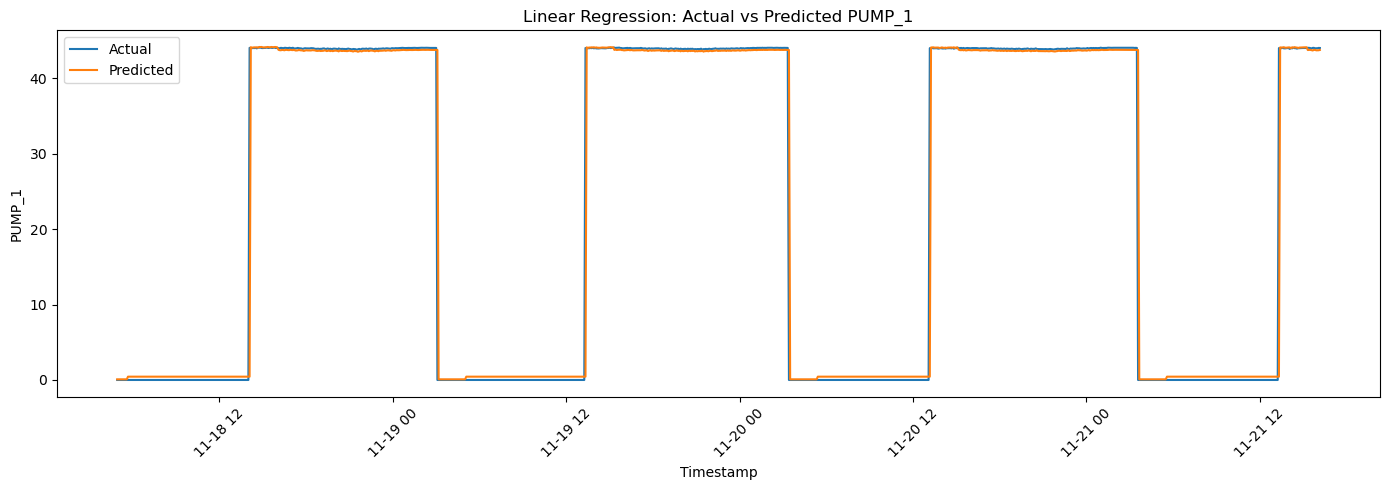

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    y_test.index[:1000],
    y_test.values[:1000],
    label="Actual"
)

plt.plot(
    y_test.index[:1000],
    y_pred_lr_test[:1000],
    label="Predicted"
)

plt.title("Linear Regression: Actual vs Predicted PUMP_1")
plt.xlabel("Timestamp")
plt.ylabel("PUMP_1")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [89]:
# Number of future steps: 24 hours × 12 observations per hour
forecast_steps = 288

# Start with the most recent known PUMP_1 values
history = ml_df["PUMP_1"].tolist()

future_predictions = []

for _ in range(forecast_steps):

    # Create lag features from the most recent history
    features = np.array([[
        history[-1],    # lag1
        history[-2],    # lag2
        history[-3],    # lag3
        history[-6],    # lag6
        history[-12],   # lag12
        history[-24]    # lag24
    ]])

    # Predict next PUMP_1 value
    prediction = lr_model.predict(features)[0]

    # Store prediction
    future_predictions.append(prediction)

    # Add prediction to history for the next forecast
    history.append(prediction)

print("Future forecasts generated:", len(future_predictions))
print("First 5 forecasts:", future_predictions[:5])

Future forecasts generated: 288
First 5 forecasts: [np.float64(43.77160786450252), np.float64(43.505449131709945), np.float64(43.241493697267224), np.float64(42.97933241363327), np.float64(42.71927270028093)]


C:\Users\malus\.thumbnails\fail\blender\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\malus\.thumbnails\fail\blender\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\malus\.thumbnails\fail\blender\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\malus\.thumbnails\fail\blender\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\malus\.thumbnails\fail\blender\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegressi

In [90]:
# Number of future steps: 24 hours
forecast_steps = 288

# Start with the latest known PUMP_1 values
history = ml_df["PUMP_1"].tolist()

future_predictions = []

feature_names = [
    "PUMP_1_lag1",
    "PUMP_1_lag2",
    "PUMP_1_lag3",
    "PUMP_1_lag6",
    "PUMP_1_lag12",
    "PUMP_1_lag24"
]

for _ in range(forecast_steps):

    # Create lag features
    features = pd.DataFrame([[
        history[-1],
        history[-2],
        history[-3],
        history[-6],
        history[-12],
        history[-24]
    ]], columns=feature_names)

    # Predict next value
    prediction = lr_model.predict(features)[0]

    future_predictions.append(prediction)

    # Add prediction to history
    history.append(prediction)

print("Future forecasts generated:", len(future_predictions))
print("First 5 forecasts:", future_predictions[:5])

Future forecasts generated: 288
First 5 forecasts: [np.float64(43.77160786450252), np.float64(43.505449131709945), np.float64(43.241493697267224), np.float64(42.97933241363327), np.float64(42.71927270028093)]


In [91]:
# Create timestamps for the next 24 hours
future_timestamps = pd.date_range(
    start=forecast_df.index[-1] + pd.Timedelta(minutes=5),
    periods=288,
    freq="5min"
)

# Create forecast DataFrame
future_forecast_df = pd.DataFrame(
    {
        "PUMP_1_Forecast": future_predictions
    },
    index=future_timestamps
)

# Display the first and last 5 forecasts
print(future_forecast_df.head())
print(future_forecast_df.tail())

# Display shape
print("Forecast shape:", future_forecast_df.shape)

                     PUMP_1_Forecast
2019-01-01 00:00:00        43.771608
2019-01-01 00:05:00        43.505449
2019-01-01 00:10:00        43.241494
2019-01-01 00:15:00        42.979332
2019-01-01 00:20:00        42.719273
                     PUMP_1_Forecast
2019-01-01 23:35:00        27.346296
2019-01-01 23:40:00        27.345406
2019-01-01 23:45:00        27.344535
2019-01-01 23:50:00        27.343682
2019-01-01 23:55:00        27.342848
Forecast shape: (288, 1)


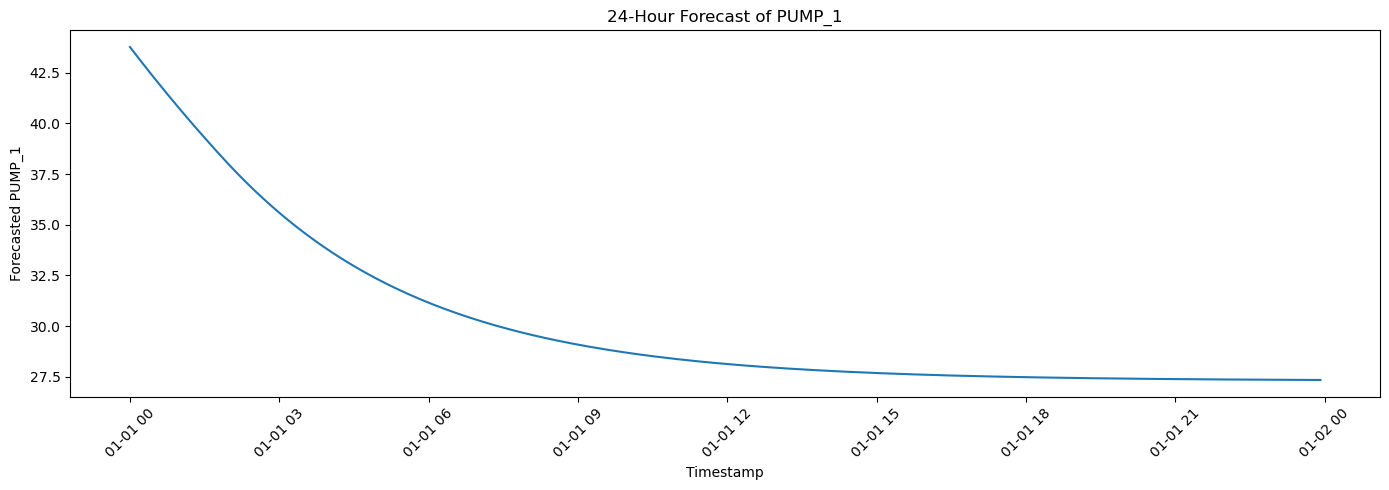

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    future_forecast_df.index,
    future_forecast_df["PUMP_1_Forecast"]
)

plt.title("24-Hour Forecast of PUMP_1")
plt.xlabel("Timestamp")
plt.ylabel("Forecasted PUMP_1")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [93]:
future_forecast_df.to_csv("PUMP_1_24_hour_forecast.csv")

print("Forecast saved successfully.")

Forecast saved successfully.


In [94]:
import joblib

joblib.dump(lr_model, "pump1_forecast_model.pkl")

print("Forecasting model saved successfully.")

Forecasting model saved successfully.


In [95]:
last_24_values = ml_df["PUMP_1"].iloc[-24:].tolist()

joblib.dump(last_24_values, "pump1_history.pkl")

print("PUMP_1 history saved successfully.")

PUMP_1 history saved successfully.
